# Василенко Даниил Олегович, СКТ-125

| Вариант  | ПУНКТ 2 | ПУНКТ 3 | ПУНКТ 4 | ПУНКТ 6 | ПУНКТ 8 | ПУНКТ 9 | ПУНКТ 10 |
|----------|---------|---------|---------|---------|---------|---------|----------|
| 7 | Apriori, 5%  | ice_crea | 40% | Closeness | PCA | tSNE | 6 |

Объектом анализа является транзакция.
Признаки:
1. Customer — кто покупает
2. Product — что покупают
3. Time — когда покупают

In [1]:
import pandas as pd

# Пункт 1
Загрузите файл «assc_TRANSACTION.csv».
В нем три колонки Customer – ID клиента, Product – покупка, Time – временная метка (для задания не нужна).
Определите (написав соответствующий код) сколько различных значений принимают переменные Product и Customer.

In [2]:
# Загрузка файла TRANSACTION.csv
csv = "TRANSACTION.csv"
df = pd.read_csv(csv)

In [3]:
# вывод наименования колонок
print(df.columns)

Index(['CUSTOMER', 'TIME', 'PRODUCT'], dtype='str')


In [4]:
col_name_product = "PRODUCT"
col_name_customer = "CUSTOMER"

In [5]:
unumber_product = df[col_name_product].nunique()
print(f"Количество уникальных значений {col_name_product}: {unumber_product}")

unumber_customer = df[col_name_customer].nunique()
print(f"Количество уникальных значений {col_name_customer}: {unumber_customer}")

Количество уникальных значений PRODUCT: 20
Количество уникальных значений CUSTOMER: 1001


# Пункт 2
Найдите частые эпизоды с ограничением на размер правила равным 4,
с использованием алгоритма **Apriori** и порога на поддержку **5%**. 

In [6]:
# подготовка данных для алгоритма Apriori
transactions = []
for transaction, group in df.groupby([col_name_customer])[col_name_product]:
    basket = group.tolist()
    transactions.append(basket)

In [7]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
# fit запоминает уникальные товары
# transform строит булеву матрицу
# DataFrame делает удобную таблицу для apriori
te_ary = te.fit(transactions).transform(transactions)
print(te_ary.shape)
transactions_df = pd.DataFrame(te_ary, columns=te.columns_)

(1001, 20)


In [8]:
from mlxtend.frequent_patterns import apriori

frequent_itemsets = apriori(transactions_df, min_support=0.05, use_colnames=True, max_len=4)

print("Частые эпизоды с ограничением на размер правила равным 4.")
print(f"Найдено {len(frequent_itemsets)} наборов.")

Частые эпизоды с ограничением на размер правила равным 4.
Найдено 360 наборов.


# Пункт 3
Найдите самый большой (где больше всего элементов) частый эпизод, содержащий продукт
**ice_crea**. Какая у него поддержка?

In [9]:
frequent_itemsets["itemset_len"] = frequent_itemsets["itemsets"].apply(lambda i: len(i))

In [10]:
search = 'ice_crea'
mask = frequent_itemsets["itemsets"].apply(lambda i: search in i)
ice_sets = frequent_itemsets[mask]
max_len_ice = ice_sets["itemset_len"].max()
largest_ice_sets = ice_sets[ice_sets["itemset_len"] == max_len_ice]

### Самые большие частые эпизоды с указанием поддержки

In [11]:
print(largest_ice_sets)

      support                                           itemsets  itemset_len
336  0.096903       frozenset({bourbon, ice_crea, olives, coke})            4
337  0.095904       frozenset({bourbon, ice_crea, coke, turkey})            4
344  0.095904     frozenset({bourbon, ice_crea, olives, turkey})            4
345  0.115884     frozenset({chicken, ice_crea, coke, heineken})            4
347  0.115884     frozenset({sardines, ice_crea, coke, chicken})            4
349  0.115884  frozenset({chicken, sardines, ice_crea, heinek...            4
350  0.116883    frozenset({sardines, ice_crea, coke, heineken})            4
351  0.094905        frozenset({ice_crea, olives, coke, turkey})            4


# Пункт 4
На основе найденных частых эпизодов постройте ассоциативные правила с порогом на
достоверность **40%**. Найдите правило с максимальным лифтом,
содержащем продукт **ice_crea** в левой части правила. Дайте ему письменную
словесную интерпретацию, укажите и объясните его числовые показатели: поддержку,
достоверность и подъем.

In [12]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)
mask = rules["antecedents"].apply(lambda i: search in i)
antecedents_sets = rules[mask]

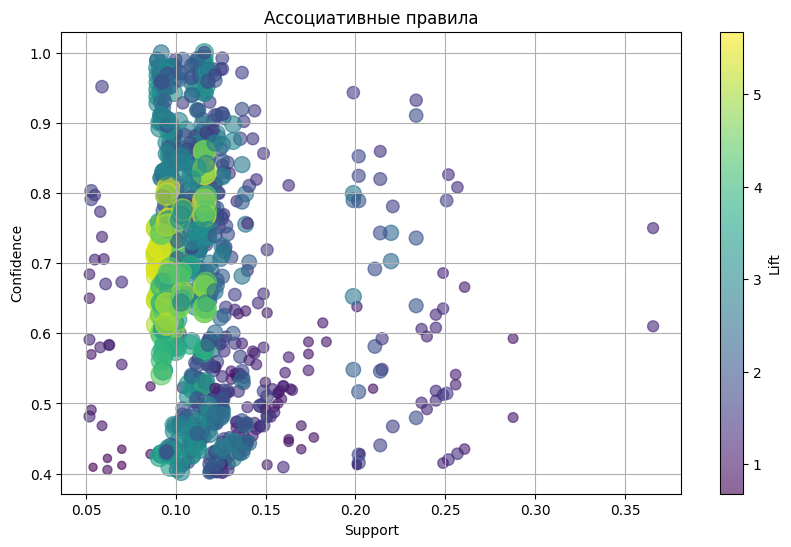

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

scatter = plt.scatter(
    rules["support"],
    rules["confidence"],
    c=rules["lift"],
    s=rules["lift"] * 50,
    alpha=0.6
)

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Ассоциативные правила")

plt.colorbar(scatter, label="Lift")
plt.grid(True)

plt.show()

Анализ показывает, что большинство правил сосредоточено в области низкой поддержки, что характерно для реальных транзакционных данных: большинство комбинаций товаров встречается относительно редко.

При этом наблюдается ряд правил с высокой достоверностью, что указывает на устойчивые зависимости между товарами. Наиболее интересными являются точки с большим значением lift, так как они отражают наиболее сильные ассоциативные связи, выходящие за рамки случайных совпадений.

In [14]:
best_rule = antecedents_sets[antecedents_sets["lift"] == antecedents_sets["lift"].max()]

antecedents = ", ".join(best_rule["antecedents"].values[0])
consequents = ", ".join(best_rule["consequents"].values[0])
support = round(best_rule["support"].values[0] * 100, 2)
confidence = round(best_rule["confidence"].values[0] * 100, 2)
lift = round(best_rule["lift"].values[0], 2)

print(f"""
Правило с максимальным значением lift:
{{{antecedents}}} → {{{consequents}}}
Support - доля клиентов ({support}%), у которых одновременно встречаются товары обеих категорий.
Confidence - условная вероятность ({confidence}%) покупки правой части при условии наличия левой.
Lift - указывает, что совместная покупка происходит в {lift} раз чаще, , чем если бы покупки были независимыми.
""")


Правило с максимальным значением lift:
{ice_crea, chicken} → {sardines, coke}
Support - доля клиентов (11.59%), у которых одновременно встречаются товары обеих категорий.
Confidence - условная вероятность (82.86%) покупки правой части при условии наличия левой.
Lift - указывает, что совместная покупка происходит в 5.64 раз чаще, , чем если бы покупки были независимыми.



### Пояснение

Из этого следует, что наличие в корзине ice_crea существенно увеличивает вероятность покупки товаров coke, sardines

## Пункт 5

Используя только двухместные правила постройте ориентированный граф, где вершины
элементы правила, их цвет (или размер) – поддержка элемента (item support), дуги –
импликации (ориентированы в направлении от условия к следствию), веса дугu –
достоверности.

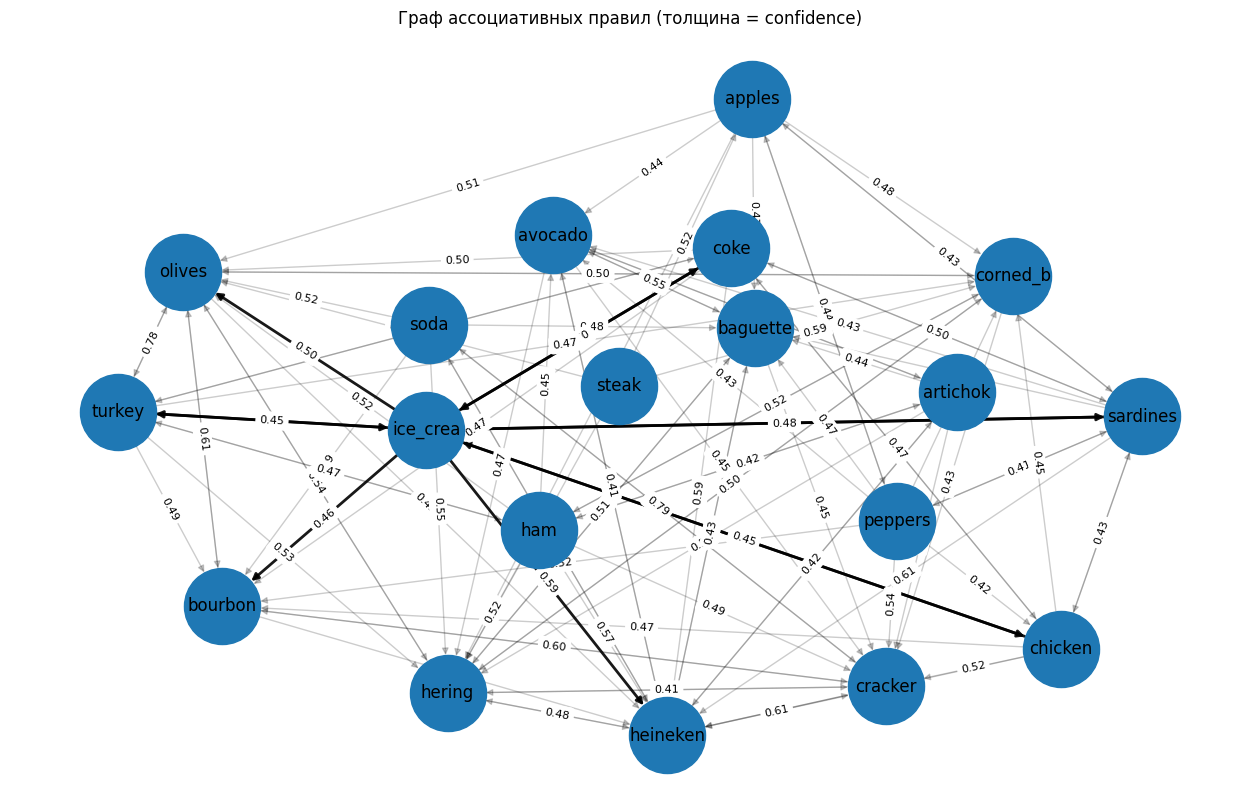

In [15]:
mask = (rules["antecedents"].apply(lambda i: len(i) == 1)) & (rules["consequents"].apply(lambda i: len(i) == 1))
pair_rules  = rules[mask]

import networkx as nx

G = nx.DiGraph()

# Построение ориентированного графа
for _, row in pair_rules.iterrows():
    source = next(iter(row["antecedents"]))
    target = next(iter(row["consequents"]))
    G.add_edge(source, target, weight=row["confidence"])

node_size = 3000

# позиционирование вершин
pos = nx.spring_layout(G, k=1.5, seed=5)

plt.figure(figsize=(16, 10))

# рисуем вершины
nx.draw_networkx_nodes(G, pos, node_size=node_size)

# рисуем рёбра
# разделяем рёбра
edges_normal = []
edges_ice = []

for u, v in G.edges():
    if u == "ice_crea" or v == "ice_crea":
        edges_ice.append((u, v))
    else:
        edges_normal.append((u, v))

# обычные рёбра (бледные)
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_normal,
    width=1,
    alpha=0.2,
    arrows=True,
    node_size=node_size
)

# выделенные рёбра
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=edges_ice,
    width=2,
    alpha=0.9,
    arrows=True,
    node_size=node_size
)

edge_labels = {(u, v): f"{d['weight']:.2f}" for u, v, d in G.edges(data=True)}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

# подписи вершин
nx.draw_networkx_labels(G, pos)

plt.title("Граф ассоциативных правил (толщина = confidence)")
plt.axis('off')
plt.show()

## Пункт 6

Для данного графа рассчитайте меры центральности **Closeness** и найдите
элемент с самой высокой мерой, а также какую меру имеет продукт **ice_crea**.


Для оценки роли товаров в структуре ассоциативных зависимостей используется мера closeness centrality.
Она характеризует «близость» вершины к другим вершинам графа и показывает, насколько быстро влияние товара может распространяться по сети правил.

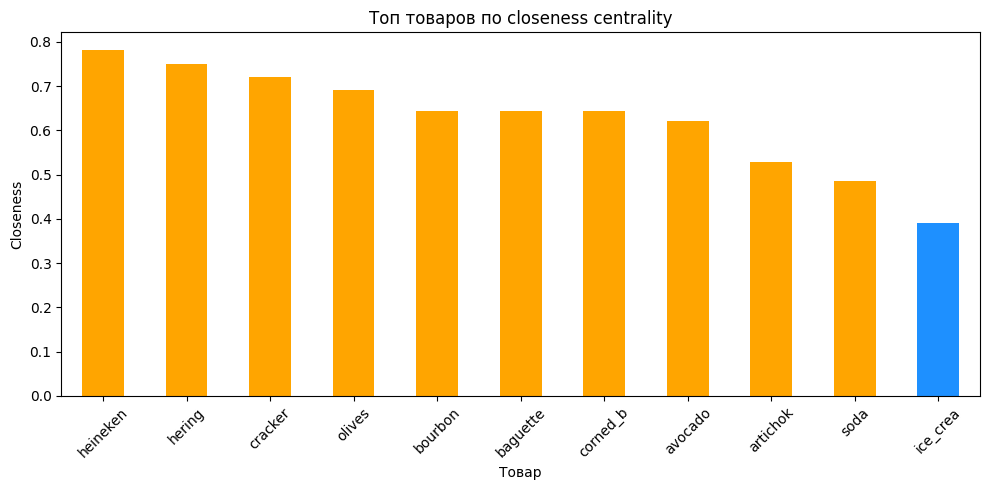

In [16]:
closeness = nx.closeness_centrality(G)

closeness_series = pd.Series(closeness).sort_values(ascending=False)

import matplotlib.pyplot as plt

top10 = closeness_series.head(10)

# добавить ice_crea если нет
if "ice_crea" not in top10.index:
    top10 = pd.concat([top10, closeness_series.loc[["ice_crea"]]])

# цвета столбцов
colors = ["dodgerblue" if item == "ice_crea" else "orange"
          for item in top10.index]

ax = top10.plot(kind="bar", color=colors, figsize=(10,5))

plt.title("Топ товаров по closeness centrality")
plt.ylabel("Closeness")
plt.xlabel("Товар")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Пояснение

График показывет вовлеченность товаров с другими товарами.

In [17]:
print(f"ice_crea имеет вовлеченность с товарами равной: {round(closeness_series.loc["ice_crea"], 2)}")

ice_crea имеет вовлеченность с товарами равной: 0.39


# Пункт 7

Постройте числовую матрицу со счетчиком числа покупок в ячейках, клиентами по строкам и
продуктами по столбцам. 

In [18]:
matrix = df.groupby(col_name_customer)[col_name_product].value_counts().unstack(fill_value=0)

# Пункт 8

С помощью метода из вашего варианта постройте линейную проекцию набора данных на
плоскость (2 компоненты) цветом укажите транзакции, содержащие продукт вашего варианта

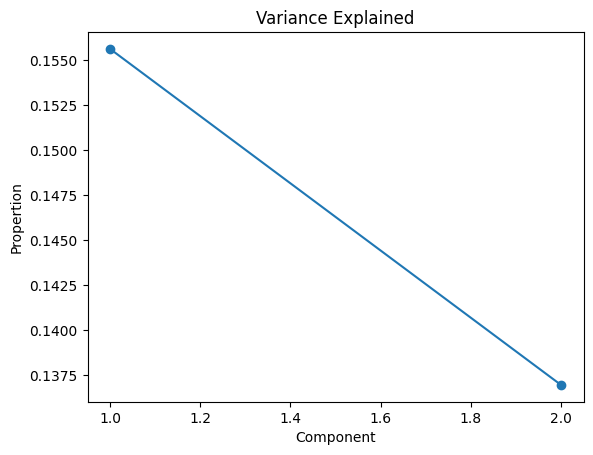

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

N = 2

pca = PCA(n_components=N)
features = pca.fit_transform(matrix)

plt.plot(range(1, N + 1), pca.explained_variance_ratio_)
plt.scatter(range(1, N + 1), pca.explained_variance_ratio_)
plt.xlabel("Component")
plt.ylabel("Propertion")
plt.title("Variance Explained")
plt.show()

In [20]:
components = pca.components_
sample = components[0]
order = np.argsort(-abs(sample))

Text(0.5, 1.0, 'components')

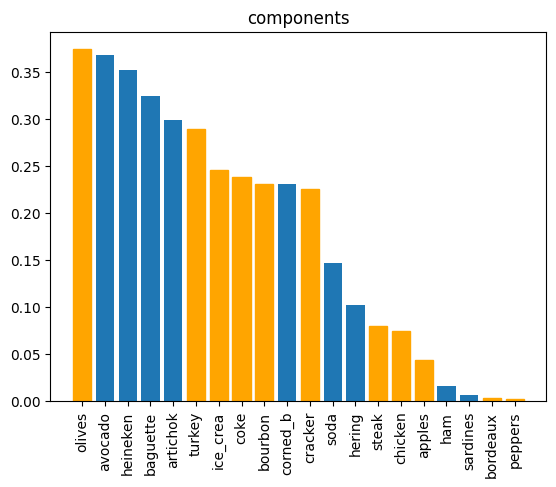

In [21]:
plt.xticks(rotation='vertical')
barplot = plt.bar(matrix.columns[order], abs(sample[order]))
[x.set_color("orange") for i, x in enumerate(barplot) if sample[i] > 0]
plt.title("components")

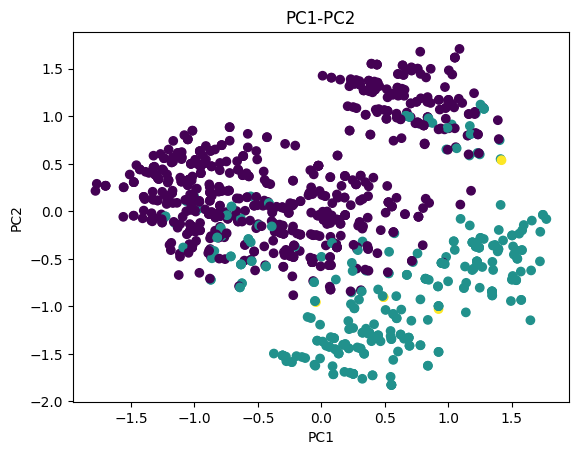

In [22]:
plt.scatter(features[:, 0], features[:, 1], c=matrix["ice_crea"])
plt.title("PC1-PC2")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

### Пояснение

Тёмный фиолетовый - клиент не покупал ice_crea

Зелёно-жёлтые оттенки - покупал 1 раз и более. Это наш исследуемый сегмент рынка.

# Пункт 9

С помощью метода **tSNE** постройте нелинейную проекцию набора данных на
плоскость цветом укажите транзакции, содержащие продукт **ice_crea**.

> Не указанные в задании параметры (например, размер решетки для SOM или число слоев в
автоэнкодере можно выбирать на свое усмотрение для получение наиболее удобной
визуализации).

Дайте письменный комментарий, чем с вашей точки зрения для вашего примера лучше или хуже нелинейная проекция).

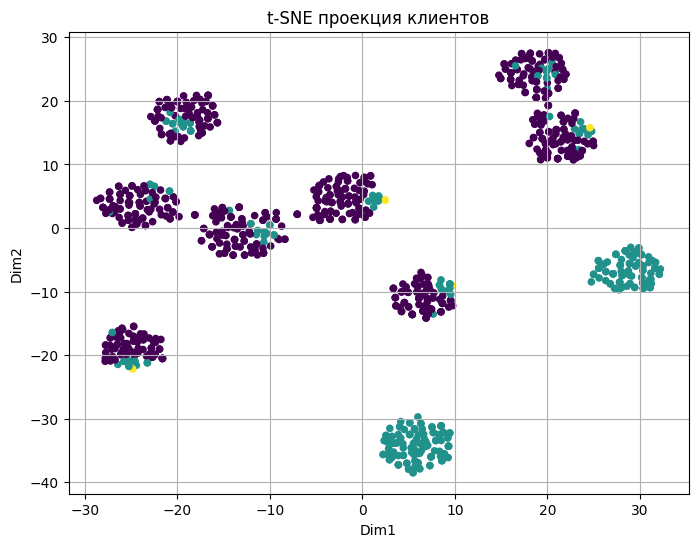

In [23]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    random_state=777,
    perplexity=50, # количество локальных соседей - сжатие (приближение)
    init='pca'
)

X_tsne = tsne.fit_transform(matrix)

plt.figure(figsize=(8,6))
plt.scatter(
    X_tsne[:,0],
    X_tsne[:,1],
    c=matrix["ice_crea"],
    s=20
)
plt.title("t-SNE проекция клиентов")
plt.xlabel("Dim1")
plt.ylabel("Dim2")
plt.grid()
plt.show()

### Пояснение

На графике t-SNE можно различить кластеры (сегменты рынка).
+ t-SNE более удобен для анализа локальных сегментов клиентов
+ PCA отражает общую структуру различий между покупателями

# Пункт 10

Из исходной матрицы (из пункта 7) отобрать **6** независимых переменных с использованием **пошагового метода**.

In [48]:
corr = matrix.corr().abs()

selected = []
weight = 0.25

# начинаем с самого вариативного товара
var_order = matrix.var().sort_values(ascending=False).index

for col in var_order:
    if len(selected) == 0:
        selected.append(col)
    else:
        ok = True
        for s in selected:
            if corr.loc[col, s] > weight:
                ok = False
                break
        if ok:
            selected.append(col)

    if len(selected) == 6:
        break

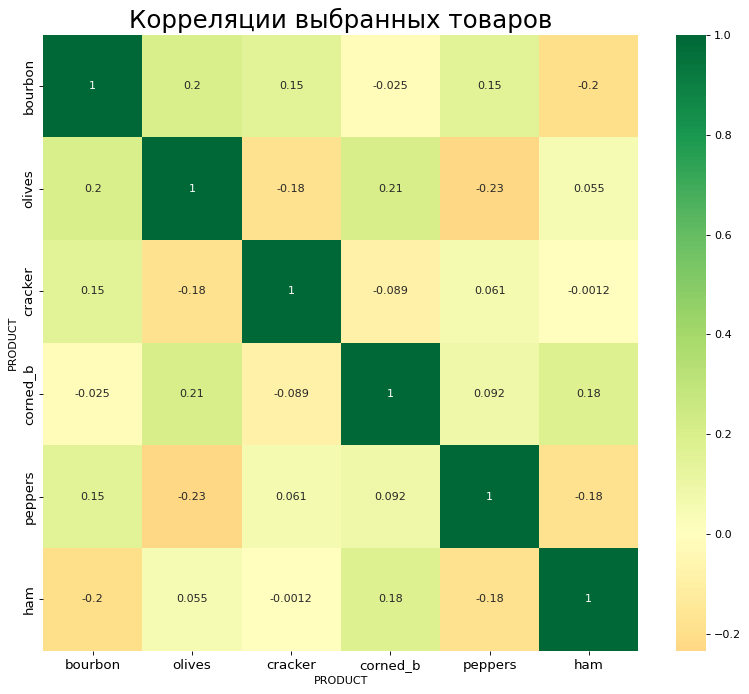

In [49]:
import seaborn as sns

corr = matrix[selected].corr()

plt.figure(figsize=(12,10), dpi= 80)
sns.heatmap(corr, xticklabels=corr.columns, yticklabels=corr.columns, cmap='RdYlGn', center=0, annot=True)

# Decorations
plt.title('Корреляции выбранных товаров', fontsize=22)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.show()